<a href="https://colab.research.google.com/github/Jee-t-hub/Jeetz-projects/blob/new-branch/EEG_data_anomalydetection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#installing
!pip install torch torchvision torchaudio numpy scipy matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 26.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 29.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 15.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 43.5 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvjitlin

In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from scipy.signal import butter, filtfilt
import matplotlib.pyplot as plt

# Loading EEG data
file_path = "/content/Z004.txt"
eeg_data = np.loadtxt(file_path)

# Bandpass filter function (0.5-85 Hz)
def bandpass_filter(data, lowcut, highcut, fs, order=4):
    nyquist = 0.5 * fs
    low = lowcut / nyquist
    high = highcut / nyquist
    b, a = butter(order, [low, high], btype='band')
    return filtfilt(b, a, data)

# Defining EEG parameters
fs = 173.61  # Sampling rate
lowcut = 0.5  # Low cutoff frequency
highcut = 85  # High cutoff frequency

# Applying bandpass filter
filtered_eeg = bandpass_filter(eeg_data, lowcut, highcut, fs)

# Normalizing EEG data to range [-1,1]
filtered_eeg = (filtered_eeg - np.min(filtered_eeg)) / (np.max(filtered_eeg) - np.min(filtered_eeg))
filtered_eeg = 2 * filtered_eeg - 1  # Scale to [-1, 1]

# Converting to PyTorch tensor
eeg_tensor = torch.tensor(filtered_eeg.copy(), dtype=torch.float32).unsqueeze(1)  # Add channel dimension

In [ ]:
seq_length = 100  # Each input sequence contains 100 time steps

# Creating overlapping sequences
X = [eeg_tensor[i:i+seq_length] for i in range(len(eeg_tensor) - seq_length)]
X = torch.stack(X)

# Creating DataLoader for batching
dataset = TensorDataset(X)
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

In [ ]:
class EEG_TransformerAutoencoder(nn.Module):
    def __init__(self, input_dim=1, model_dim=128, num_heads=8, num_layers=4):
        super(EEG_TransformerAutoencoder, self).__init__()
        self.embedding = nn.Linear(input_dim, model_dim)  # Map input to model_dim
        self.transformer = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(d_model=model_dim, nhead=num_heads),
            num_layers=num_layers
        )
        self.fc = nn.Linear(model_dim, input_dim)  # Output same shape as input

    def forward(self, x):
        x = self.embedding(x)  # Converting to model_dim
        x = x.permute(1, 0, 2)
        x = self.transformer(x)
        x = x.permute(1, 0, 2)  # Converting back to (batch, seq_length, model_dim)
        return self.fc(x)  # reconstructed EEG output

# Initializing model
model = EEG_TransformerAutoencoder()
criterion = nn.MSELoss()  # Reconstruction loss
optimizer = optim.Adam(model.parameters(), lr=0.001)

/usr/local/lib/python3.11/dist-packages/torch/nn/modules/transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


In [ ]:
num_epochs = 50
for epoch in range(num_epochs):
    total_loss = 0
    for batch_X in dataloader:
        batch_X = batch_X[0]  # Extracting data from tuple
        optimizer.zero_grad()
        reconstructed = model(batch_X)
        loss = criterion(reconstructed, batch_X)  # Reconstruction loss
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss/len(dataloader):.4f}")

Epoch 1, Loss: 0.3151
Epoch 2, Loss: 0.0044
Epoch 3, Loss: 0.0016
Epoch 4, Loss: 0.0011


KeyboardInterrupt: 

In [ ]:
# loss was  already 0.0011 at epoch 4
#so stopped training to avoid overfitting

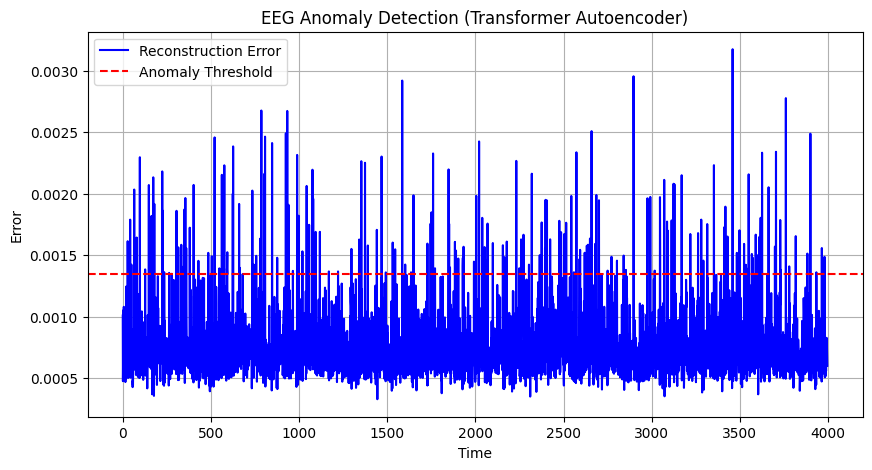

In [ ]:
# Computing reconstruction error for all EEG sequences
reconstruction_errors = []
threshold = 0  # finding a good threshold

with torch.no_grad():
    for batch_X in dataloader:
        batch_X = batch_X[0]
        reconstructed = model(batch_X)
        loss = torch.mean((batch_X - reconstructed) ** 2, dim=1)  # Per sequence loss
        reconstruction_errors.extend(loss.numpy())

# Setting anomaly threshold
threshold = np.percentile(reconstruction_errors, 95)

# Marking anomalies
anomalies = [1 if err > threshold else 0 for err in reconstruction_errors]

# Plotting results
plt.figure(figsize=(10, 5))
plt.plot(reconstruction_errors, label="Reconstruction Error", color="blue")
plt.axhline(y=threshold, color="red", linestyle="--", label="Anomaly Threshold")
plt.xlabel("Time")
plt.ylabel("Error")
plt.title("EEG Anomaly Detection (Transformer Autoencoder)")
plt.legend()
plt.grid()
plt.show()

In [ ]:
#analyzing data

Here, spikes above the threashood indicates potrntzisl anomalies , seizure like activites or signal artifacts.
Most of the data points have low reconstruction error meaning they are likely ***Normal*** eeg patterns!